# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [13]:
%pip show torch

Name: torch
Version: 2.7.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: openml-pytorch, pytorch-lightning, torchaudio, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install rdkit
%pip install torch_geometric
%pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Note: you may need to restart the kernel to use updated packages.


In [15]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

In [16]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [17]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [18]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


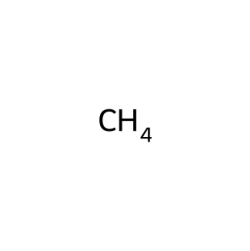

In [19]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  O  │  8   │    -0.874│     1.146│    -0.563
  C  │  6   │     0.143│     0.900│     0.035
  C  │  6   │     1.367│     1.806│     0.077
  C  │  6   │     1.248│     3.063│    -0.814
  C  │  6   │     0.880│     3.838│     0.473
  N  │  7   │     1.404│     2.706│     1.269
  C  │  6   │     0.742│     2.337│     2.514
  C  │  6   │     0.940│     3.362│     3.536
  C  │  6   │     1.082│     4.215│     4.369
  H  │  1   │     0.233│    -0.031│     0.641
  H  │  1   │     2.267│     1.184│    -0.012
  H  │  1   │     2.203│     3.365│    -1.247
  H  │  1   │     0.479│     3.010│    -1.583
  H  │  1   │     1.385│     4.788│     0.668
  H  │  1   │    -0.206│     3.981│     0.578
  H  │  1   │    -0.346│     2.171│     2.393
  H  │  1   │     1.169│     1.387│     2.863
  H  │  1   │     1.214│     4.964│     5.110


SMILE: C#CC[N@@H+]1CC[C@@H]1C=O


Formation Energy: -76.351
Formation Energy (

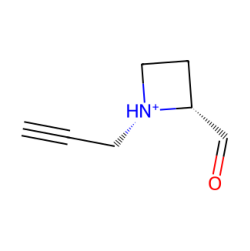

In [20]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [25]:
# Print example of pos, type data
print("pos", pos_data[0])
print("type", type_data[0])


def create_graph_data(pos, typ, fe):
    # Convert to tensor
    pos_tensor = torch.tensor(pos, dtype=torch.float)
    type_tensor = torch.tensor(typ, dtype=torch.long)
    fe_tensor = torch.tensor(fe, dtype=torch.float)

    # Create edge index
    num_atoms = len(pos)
    edge_index = []
    for i in range(num_atoms):
        for j in range(num_atoms):
            if i != j:
                edge_index.append([i, j])    
    edge_index = torch.tensor(edge_index, dtype=torch.long)

    data = Data(x=type_tensor.unsqueeze(-1).float(), pos=pos_tensor, edge_index=edge_index, y=fe_tensor)
    return data

# Smile is string data, create a dataset for it
def create_smiles_data(smile, fe):
    mol = Chem.MolFromSmiles(smile)
    if mol is None:
        return None
    AllChem.Compute2DCoords(mol)
    pos = mol.GetConformer().GetPositions()
    typ = [atom.GetAtomicNum() for atom in mol.GetAtoms()]
    return Data(x=np.array(typ).reshape(-1, 1), pos=pos, y=fe)

# Create graph data for training and testing
train_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in train_idxes]
test_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in test_idxes]
train_smiles_data = [create_smiles_data(smiles_data[i], fe[i]) for i in train_idxes]
test_smiles_data = [create_smiles_data(smiles_data[i], fe[i]) for i in test_idxes]

# Create DataLoader for training and testing
graph_train_loader = DataLoader(train_graph_data, batch_size=32, shuffle=True)
graph_test_loader = DataLoader(test_graph_data, batch_size=32, shuffle=False)
smile_train_loader = DataLoader(train_smiles_data, batch_size=32, shuffle=True)
smiles_test_loader = DataLoader(test_smiles_data, batch_size=32, shuffle=False)

print(train_graph_data[0])
print(train_smiles_data[0])

pos [[-1.2700e-02  1.0858e+00  8.0000e-03]
 [ 2.2000e-03 -6.0000e-03  2.0000e-03]
 [ 1.0117e+00  1.4638e+00  3.0000e-04]
 [-5.4080e-01  1.4475e+00 -8.7660e-01]
 [-5.2380e-01  1.4379e+00  9.0640e-01]]
type [6 1 1 1 1]


c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


Data(x=[16, 1], edge_index=[240, 2], y=0.7149152159690857, pos=[16, 3])
Data(x=[9, 1], y=0.7149152, pos=[9, 3])


In [ ]:
class Node_Embedding(nn.Module):
    def __init__ (self, node_feature_dim, node_embedding_dim):
        super(Node_Embedding, self).__init__()
        self.embedding_dim = node_embedding_dim
        self.feature_dim = node_feature_dim
        self.embedding = nn.Linear(node_feature_dim, node_embedding_dim)
    def forward(self, nodes):
        assert nodes.size(-1) == self.feature_dim, 'wrong input dimension of node features!'
        out = self.embedding(nodes)
        return out
    
# Message Passing Layer
class MP_layer(nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MP_layer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1)
        edge_messages_output = self.edge_network(edge_messages_input)
        
        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )

        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor
    
# GNN
class FormationEnergyGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3):
        super(FormationEnergyGNN, self).__init__()
        self.node_to_emb = Node_Embedding(node_feat_dim, hidden_dim)
        self.forward_net = nn.Sequential(
            *[MP_layer(hidden_dim, activation) for i in range(num_layers)]
        )
        self.to_pred = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model
        
        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))

        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x)

        x = self.to_pred(out)
        return x
    
gnn = FormationEnergyGNN(node_feat_dim=14, hidden_dim=32, num_layers=5)

## Task 2

## Task 3

In [22]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [23]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [24]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)